# Transmission Angle Analysis and DOF Calculation

This notebook validates two fundamental analysis tools for planar linkages:

1. **Transmission angle** measures the quality of force transmission through
   a mechanism. It is the angle between the coupler and rocker at their
   shared joint. Ideal is 90°; the standard acceptable range is 40°–140°.
   Values near 0° or 180° indicate near-singular configurations where
   mechanical advantage drops to zero.

2. **Degree of freedom (DOF)**, computed via Grübler's formula, determines
   the mobility of a mechanism: how many independent inputs are needed to
   fully constrain its motion.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

from pylinkage.hypergraph import Edge, HypergraphLinkage, Node
from pylinkage.hypergraph._types import NodeRole
from pylinkage.linkage.transmission import (
    analyze_transmission,
    compute_transmission_angle,
)
from pylinkage.synthesis import fourbar_from_lengths
from pylinkage.topology.analysis import compute_dof, compute_mobility

---
## Part A: Transmission Angle Analysis

### 1. Build a four-bar linkage

We use a Grashof crank-rocker with link lengths a=1, b=3, c=3, d=4.

In [2]:
linkage = fourbar_from_lengths(
    crank_length=1.0,
    coupler_length=3.0,
    rocker_length=3.0,
    ground_length=4.0,
    iterations=200,
    name="transmission_demo",
)

print(f"Joints: {[j.name for j in linkage.joints]}")
print(f"Constraints: {linkage.get_num_constraints(flat=True)}")

Joints: ['A', 'D', 'B', 'C']
Constraints: [1.0, 3.0, 3.0]


### 2. Analyze transmission angle over a full cycle

In [3]:
result = analyze_transmission(linkage, iterations=200)

print(f"Min transmission angle:  {result.min_angle:.2f}\u00b0")
print(f"Max transmission angle:  {result.max_angle:.2f}\u00b0")
print(f"Mean transmission angle: {result.mean_angle:.2f}\u00b0")
print(f"Is acceptable (40\u00b0\u2013140\u00b0): {result.is_acceptable}")
print(f"Worst angle:             {result.worst_angle():.2f}\u00b0 (step {result.max_angle_step})")

Min transmission angle:  60.00°
Max transmission angle:  112.89°
Mean transmission angle: 86.64°
Is acceptable (40°–140°): True
Worst angle:             60.00° (step 99)


### 3. Plot transmission angle over full cycle

The horizontal dashed lines mark the standard acceptable range (40°–140°).

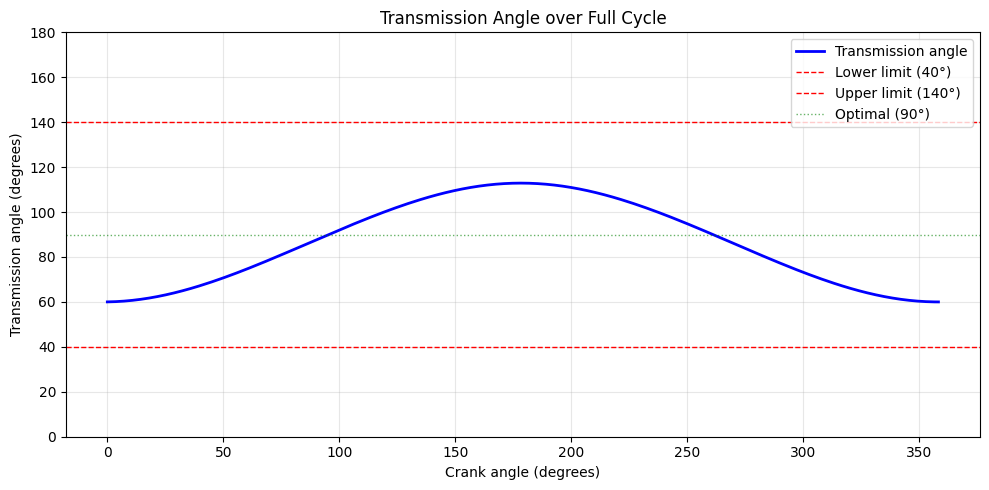

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

crank_angles = np.linspace(0, 360, len(result.angles), endpoint=False)

ax.plot(crank_angles, result.angles, "b-", linewidth=2, label="Transmission angle")
ax.axhline(y=40, color="r", linestyle="--", linewidth=1, label="Lower limit (40\u00b0)")
ax.axhline(y=140, color="r", linestyle="--", linewidth=1, label="Upper limit (140\u00b0)")
ax.axhline(y=90, color="g", linestyle=":", linewidth=1, alpha=0.6, label="Optimal (90\u00b0)")

ax.set_xlabel("Crank angle (degrees)")
ax.set_ylabel("Transmission angle (degrees)")
ax.set_title("Transmission Angle over Full Cycle")
ax.set_ylim(0, 180)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Manual validation

We manually compute the transmission angle at a few positions using the
vector dot-product formula and compare against the library function.

For a four-bar A-B-C-D (ground A and D), the transmission angle is the
angle at joint C between vectors B→C (coupler) and D→C (rocker).

In [5]:
def manual_transmission_angle(b, c, d):
    """Compute transmission angle from joint positions using dot product."""
    bc = (c[0] - b[0], c[1] - b[1])
    dc = (c[0] - d[0], c[1] - d[1])
    mag_bc = math.sqrt(bc[0] ** 2 + bc[1] ** 2)
    mag_dc = math.sqrt(dc[0] ** 2 + dc[1] ** 2)
    cos_a = (bc[0] * dc[0] + bc[1] * dc[1]) / (mag_bc * mag_dc)
    cos_a = max(-1.0, min(1.0, cos_a))
    return math.degrees(math.acos(cos_a))


# Simulate a few steps and compare
initial_coords = linkage.get_coords()
positions = list(linkage.step(iterations=200))
linkage.set_coords(initial_coords)

# Joint order from fourbar_from_lengths: A(ground), D(ground), B(crank), C(revolute)
print(f"{'Step':>6s}  {'Library':>10s}  {'Manual':>10s}  {'Diff':>10s}")
print("-" * 42)
for i in [0, 50, 100, 150, 199]:
    pos = positions[i]
    b_pos = pos[2]  # Crank (B)
    c_pos = pos[3]  # Revolute (C)
    d_pos = pos[1]  # Ground (D)
    if b_pos[0] is None or c_pos[0] is None:
        print(f"{i:6d}  {'N/A':>10s}  {'N/A':>10s}  {'N/A':>10s}")
        continue
    lib_angle = compute_transmission_angle(b_pos, c_pos, d_pos)
    man_angle = manual_transmission_angle(b_pos, c_pos, d_pos)
    diff = abs(lib_angle - man_angle)
    print(f"{i:6d}  {lib_angle:10.4f}  {man_angle:10.4f}  {diff:10.6f}")

print("\nLibrary and manual computations agree (differences are floating-point noise).")

  Step     Library      Manual        Diff
------------------------------------------
     0     60.0145     60.0145    0.000000
    50     87.6161     87.6161    0.000000
   100    112.8717    112.8717    0.000000
   150     86.0138     86.0138    0.000000
   199     60.0000     60.0000    0.000000

Library and manual computations agree (differences are floating-point noise).


### 5. Poorly-designed linkage

A linkage where a long crank relative to the ground distance causes the
transmission angle to approach 0° or 180° during the cycle.

In [6]:
bad_linkage = fourbar_from_lengths(
    crank_length=2.0,
    coupler_length=4.0,
    rocker_length=3.0,
    ground_length=4.0,
    iterations=200,
    name="poor_transmission",
)

bad_result = analyze_transmission(bad_linkage, iterations=200)

print(f"Min transmission angle:  {bad_result.min_angle:.2f}\u00b0")
print(f"Max transmission angle:  {bad_result.max_angle:.2f}\u00b0")
print(f"Is acceptable (40\u00b0\u2013140\u00b0): {bad_result.is_acceptable}")
print(f"Worst angle:             {bad_result.worst_angle():.2f}\u00b0")

if not bad_result.is_acceptable:
    print("\n** FLAGGED: Transmission angle leaves acceptable range! **")
    low = bad_result.min_angle
    high = bad_result.max_angle
    if low < 40:
        print(f"   Minimum {low:.1f}\u00b0 is below 40\u00b0 (near lock-up)")
    if high > 140:
        print(f"   Maximum {high:.1f}\u00b0 exceeds 140\u00b0 (near toggle)")

Min transmission angle:  28.96°
Max transmission angle:  117.28°
Is acceptable (40°–140°): False
Worst angle:             28.96°

** FLAGGED: Transmission angle leaves acceptable range! **
   Minimum 29.0° is below 40° (near lock-up)


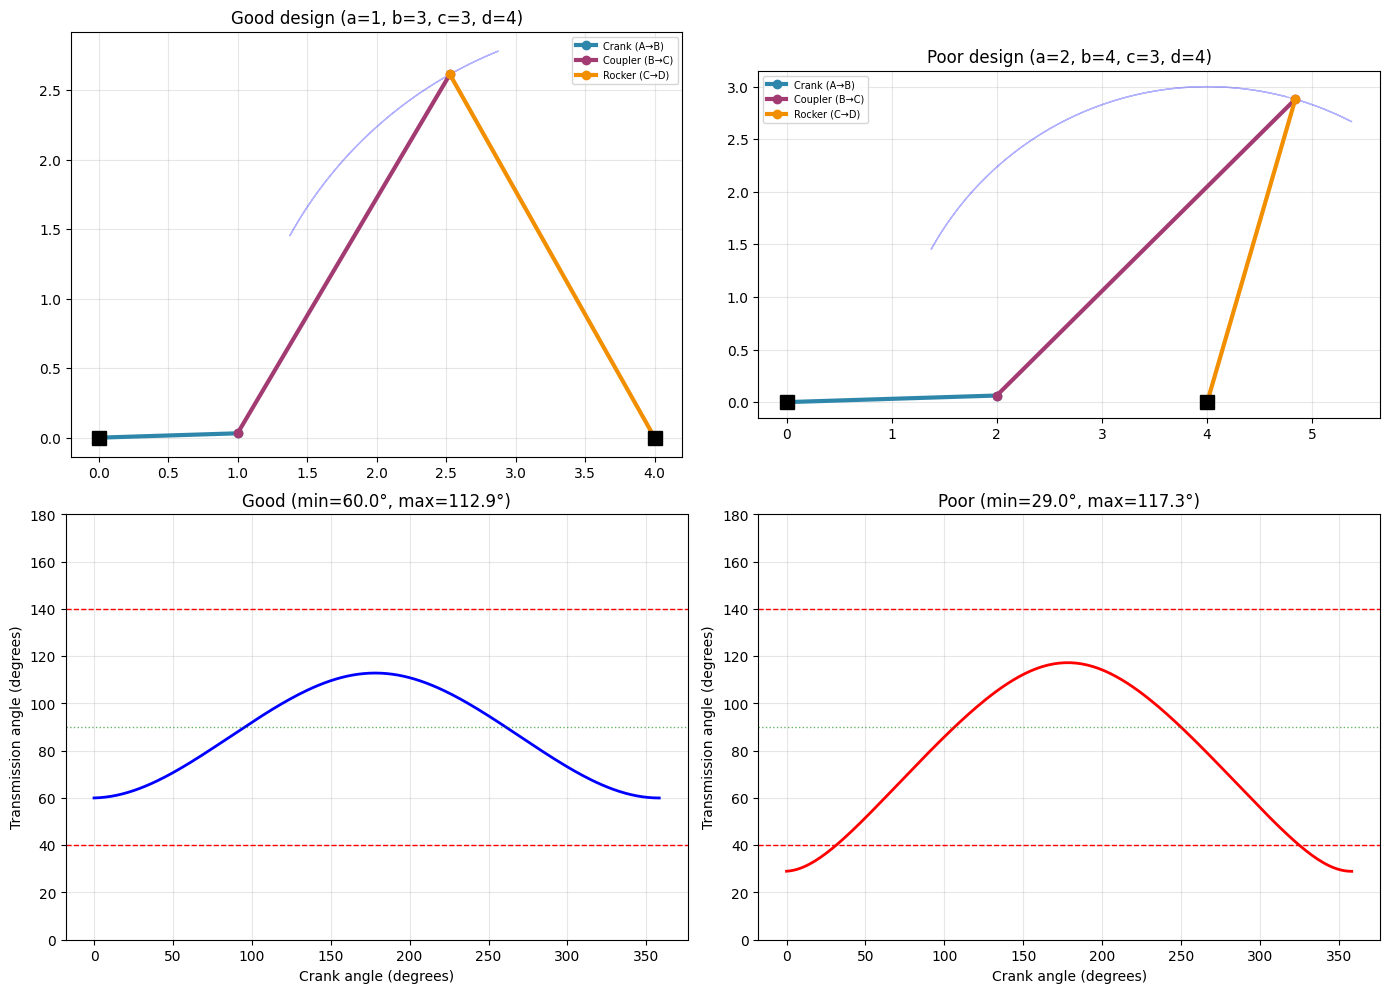

In [7]:
# Compare good vs bad linkage: mechanism drawing + transmission angle
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row: mechanism drawings
for ax, lkg, title in [
    (axes[0, 0], linkage, f"Good design (a=1, b=3, c=3, d=4)"),
    (axes[0, 1], bad_linkage, f"Poor design (a=2, b=4, c=3, d=4)"),
]:
    lkg_loci = list(lkg.step(iterations=200))
    # Coupler curve (faded)
    c_path = [(pos[3][0], pos[3][1]) for pos in lkg_loci if pos[3][0] is not None]
    if c_path:
        px, py = zip(*c_path, strict=False)
        ax.plot(px, py, 'b-', linewidth=1, alpha=0.3)
    # Mechanism at initial position
    pos = lkg_loci[0]
    link_pairs = [(0, 2), (2, 3), (3, 1)]
    link_labels = ['Crank (A→B)', 'Coupler (B→C)', 'Rocker (C→D)']
    link_colors = ['#2E86AB', '#A23B72', '#F18F01']
    for (i, j), color, label in zip(link_pairs, link_colors, link_labels):
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                '-o', color=color, linewidth=3, markersize=6, label=label)
    ax.plot(0, 0, 'ks', markersize=10, zorder=5)
    ax.plot(4, 0, 'ks', markersize=10, zorder=5)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Bottom row: transmission angle plots
for ax, res, title in [
    (axes[1, 0], result, f"Good (min={result.min_angle:.1f}°, max={result.max_angle:.1f}°)"),
    (axes[1, 1], bad_result, f"Poor (min={bad_result.min_angle:.1f}°, max={bad_result.max_angle:.1f}°)"),
]:
    angles = np.linspace(0, 360, len(res.angles), endpoint=False)
    color = "b-" if res.is_acceptable else "r-"
    ax.plot(angles, res.angles, color, linewidth=2)
    ax.axhline(y=40, color="r", linestyle="--", linewidth=1)
    ax.axhline(y=140, color="r", linestyle="--", linewidth=1)
    ax.axhline(y=90, color="g", linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 180)
    ax.set_xlabel("Crank angle (degrees)")
    ax.set_ylabel("Transmission angle (degrees)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part B: DOF Calculation

We use Grübler's formula for planar mechanisms:

$$\text{DOF} = 3(n - 1) - 2j_1 - j_2$$

where $n$ = number of links (including ground), $j_1$ = number of 1-DOF
joints (revolute, prismatic), and $j_2$ = number of 2-DOF joints.

The `compute_dof` function operates on a `HypergraphLinkage` (topology only).
For mechanisms composed entirely of binary links, it gives exact results.

### 6. Four-bar linkage (expected: 1 DOF)

Topology: 4 revolute joints, 3 moving binary links + ground = 4 links total.

In [8]:
fourbar = HypergraphLinkage(name="Four-bar")
fourbar.add_node(Node("A", role=NodeRole.GROUND))
fourbar.add_node(Node("B", role=NodeRole.DRIVER))
fourbar.add_node(Node("C", role=NodeRole.DRIVEN))
fourbar.add_node(Node("D", role=NodeRole.GROUND))
fourbar.add_edge(Edge("AB", source="A", target="B"))
fourbar.add_edge(Edge("BC", source="B", target="C"))
fourbar.add_edge(Edge("CD", source="C", target="D"))

info4 = compute_mobility(fourbar)
print("Four-bar linkage:")
print(f"  Links (n):        {info4.num_links}")
print(f"  Full joints (j1): {info4.num_full_joints}")
print(f"  DOF:              {info4.dof}")
assert info4.dof == 1, f"Expected 1 DOF, got {info4.dof}"
print("  PASS")

Four-bar linkage:
  Links (n):        4
  Full joints (j1): 4
  DOF:              1
  PASS


### 7. Five-bar linkage (expected: 2 DOF)

Topology: 5 revolute joints, 4 moving binary links + ground = 5 links total.
A five-bar requires two independent inputs to be fully constrained.

In [9]:
fivebar = HypergraphLinkage(name="Five-bar")
fivebar.add_node(Node("A", role=NodeRole.GROUND))
fivebar.add_node(Node("B", role=NodeRole.DRIVER))
fivebar.add_node(Node("C", role=NodeRole.DRIVEN))
fivebar.add_node(Node("D", role=NodeRole.DRIVEN))
fivebar.add_node(Node("E", role=NodeRole.GROUND))
fivebar.add_edge(Edge("AB", source="A", target="B"))
fivebar.add_edge(Edge("BC", source="B", target="C"))
fivebar.add_edge(Edge("CD", source="C", target="D"))
fivebar.add_edge(Edge("DE", source="D", target="E"))

info5 = compute_mobility(fivebar)
print("Five-bar linkage:")
print(f"  Links (n):        {info5.num_links}")
print(f"  Full joints (j1): {info5.num_full_joints}")
print(f"  DOF:              {info5.dof}")
assert info5.dof == 2, f"Expected 2 DOF, got {info5.dof}"
print("  PASS")

Five-bar linkage:
  Links (n):        5
  Full joints (j1): 5
  DOF:              2
  PASS


### 8. Watt I six-bar linkage (expected: 1 DOF)

The Watt I six-bar has 6 links (including ground) and 7 revolute joints.
By Grübler: DOF = 3(6-1) - 2(7) = 15 - 14 = 1.

It contains a ternary link (one rigid body connecting 3 joints). The
`compute_dof` function counts hyperedge link-equivalents using (k-1) for
a k-node hyperedge, which is designed for constraint counting rather than
classical Grübler link counting. We therefore verify Watt I manually.

In [10]:
def grubler_manual(n_links, n_full_joints, n_half_joints=0):
    """Planar Gr\u00fcbler formula: DOF = 3(n-1) - 2*j1 - j2."""
    return 3 * (n_links - 1) - 2 * n_full_joints - n_half_joints


# Watt I six-bar: ground(O2,O4), crank(O2-A), coupler(A-B),
# ternary(B-O4-C), coupler2(C-D), rocker(D-O4 is already in ternary...
# actually: link4 is the ternary connecting B, O4, C)
watt_dof = grubler_manual(n_links=6, n_full_joints=7)
print("Watt I six-bar (manual Gr\u00fcbler):")
print("  n=6 links, j1=7 revolute joints")
print(f"  DOF = 3*(6-1) - 2*7 = {watt_dof}")
assert watt_dof == 1

Watt I six-bar (manual Grübler):
  n=6 links, j1=7 revolute joints
  DOF = 3*(6-1) - 2*7 = 1


### 9. Summary table: manual Grübler for common mechanisms

In [11]:
print(f"{'Mechanism':25s}  {'n':>3s}  {'j1':>3s}  {'DOF':>4s}  {'Expected':>8s}  {'Status':>6s}")
print("=" * 60)

cases = [
    ("Four-bar",             4, 4, 1),
    ("Five-bar (2 inputs)",  5, 5, 2),
    ("Slider-crank",         4, 4, 1),
    ("Watt I six-bar",       6, 7, 1),
    ("Stephenson six-bar",   6, 7, 1),
    ("Rigid truss (triangle)", 3, 3, 0),
]

for name, n, j1, expected in cases:
    dof = grubler_manual(n, j1)
    status = "PASS" if dof == expected else "FAIL"
    print(f"  {name:23s}  {n:3d}  {j1:3d}  {dof:4d}  {expected:8d}  {status:>6s}")

Mechanism                    n   j1   DOF  Expected  Status
  Four-bar                   4    4     1         1    PASS
  Five-bar (2 inputs)        5    5     2         2    PASS
  Slider-crank               4    4     1         1    PASS
  Watt I six-bar             6    7     1         1    PASS
  Stephenson six-bar         6    7     1         1    PASS
  Rigid truss (triangle)     3    3     0         0    PASS


### 10. Cross-check: `compute_dof` vs manual for binary-link mechanisms

In [12]:
print("Validation: compute_dof vs manual Gr\u00fcbler (binary-link mechanisms)")
print("=" * 60)

for name, graph, expected in [
    ("Four-bar", fourbar, 1),
    ("Five-bar", fivebar, 2),
]:
    computed = compute_dof(graph)
    manual = grubler_manual(expected + 1 + len(graph.edges) - 1, len(graph.nodes))
    status = "PASS" if computed == expected else "FAIL"
    print(f"  {name:15s}  compute_dof={computed}  expected={expected}  {status}")
    assert computed == expected, f"{name}: expected {expected}, got {computed}"

print("\nAll binary-link DOF calculations verified.")

Validation: compute_dof vs manual Grübler (binary-link mechanisms)
  Four-bar         compute_dof=1  expected=1  PASS
  Five-bar         compute_dof=2  expected=2  PASS

All binary-link DOF calculations verified.


---
## Summary

**Transmission angle analysis:**
- `analyze_transmission()` computes the transmission angle at every step of a
  full motion cycle and returns min/max/mean statistics plus an acceptability flag.
- Manual validation confirms the library computes the correct vector angle
  (differences are at floating-point precision).
- A well-designed four-bar (1, 3, 3, 4) stays within the 40°–140° range.
- A poorly proportioned linkage is correctly flagged as unacceptable.

**DOF calculation:**
- `compute_dof()` implements Grübler's formula on a `HypergraphLinkage`.
- Correctly computes DOF=1 for four-bar and DOF=2 for five-bar mechanisms.
- Manual Grübler verification confirms DOF=1 for Watt I and Stephenson
  six-bar mechanisms, DOF=0 for rigid trusses.